<center><h1>Yang_Zhonghao_HW2</h1></center>
<br>
<br>

Name:  Zhonghao Yang "Eddie"
<br>
Github Username: ZhonghaoYang-EDDIE
<br>
USC ID: 4643420428

**AI Assistance Disclosure:** AI assistance was used (Claude.ai from Anthropic) in this assignment. It was mainly used for understanding and refreshing stats concepts, as well as for help with coding logic and debugging.

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [2]:
# Load Sheet 1
df = pd.read_excel('Folds5x2_pp.xlsx', sheet_name='Sheet1')

print(df.shape)
print(df.head())
print(df.columns.tolist())

(9568, 5)
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90
['AT', 'V', 'AP', 'RH', 'PE']


### (b) Exploring the data

#### i. rows and columns

In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 9568
Number of columns: 5


**Answer:** The dataset has 9568 rows and 5 columns. Each row represents one hourly observation of the power plant's operating conditions and output.  

&emsp;&emsp; The columns are:
- **AT:** Temperature — predictor
- **V:** Exhaust Vacuum  — predictor
- **AP:** Ambient Pressure — predictor
- **RH:** Relative Humidity — predictor
- **PE:** Net hourly electrical energy output — dependent variable (the response)

#### ii. pairwise scatterplots of all the varianbles

c:\Users\15699\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


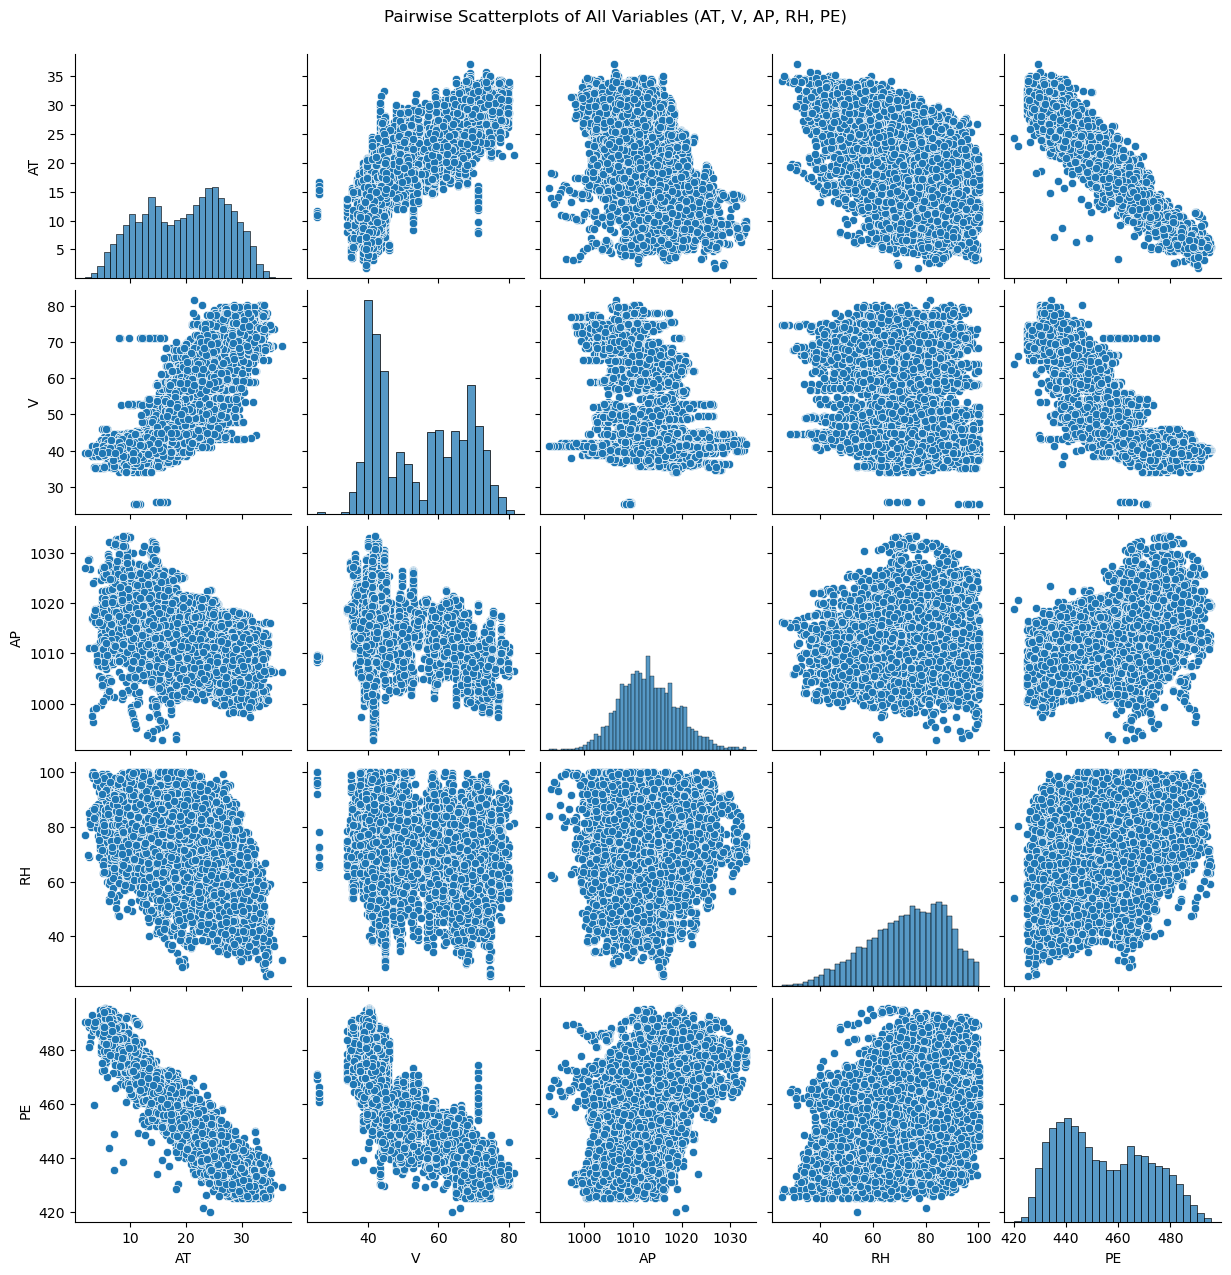

In [4]:
sns.pairplot(df)
plt.suptitle('Pairwise Scatterplots of All Variables (AT, V, AP, RH, PE)', y=1.02)
plt.show()

**My Findings:** 

From these scatterplots, AT (temperature) and V (exhaust vacuum) both show a clear negative linear relationship with PE (electric output), suggesting they may be strong predictors in a linear regression model.   

Additionally, AT and V show a trend strongly positively correlated with each other. I don't see any other distinct trends at least for now.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
stats_table = df.describe().T[['mean', '50%', 'min', 'max', '25%', '75%']]
stats_table.columns = ['Mean', 'Median', 'Min', 'Max', 'Q1', 'Q3']
stats_table['Range'] = stats_table['Max'] - stats_table['Min']
stats_table['IQR'] = stats_table['Q3'] - stats_table['Q1']

stats_table = stats_table[['Mean', 'Median', 'Range', 'Q1', 'Q3', 'IQR']]
stats_table

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [6]:

predictors = ['AT', 'V', 'AP', 'RH']

for predictor in predictors:
    X = df[predictor]
    X = sm.add_constant(X)  # adds the intercept term (beta_0)
    y = df['PE']

    model = sm.OLS(y, X).fit()
    print(f"Simple Linear Regression: PE ~ {predictor} ")
    print(model.summary())
    print("\n")

Simple Linear Regression: PE ~ AT 
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:35:41   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.

**Results:** All four predictors show statistically significant linear associations with PE (p-value = 0.000 for all), so we reject H0: β1 = 0 for each predictor.  

&emsp;&emsp; &emsp; However, the strength of these relationships are not on the same level. AT (R²=0.899) and V (R²=0.757) are strong predictors of PE individually, while AP (R²=0.269) and RH (R²=0.152) much weaker.

### (d) Multiple Regression

In [7]:
X_multi = df[['AT', 'V', 'AP', 'RH']]
X_multi = sm.add_constant(X_multi)
y = df['PE']

model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:35:41   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

**Results:**   

All four predictors (AT, V, AP, RH) have p-value = 0.000. So all are statistically significant. R² = 0.929, higher than any single regression I mentinoned above.

But some coefficients changed a lot from part (c):
- V dropped from -1.17 to -0.23
- RH flipped sign, from +0.46 to -0.16

This suggests multicollinearity, likely between AT and V, also as I mentioned in (b)(ii)

### (e) 1c Compare to 1d

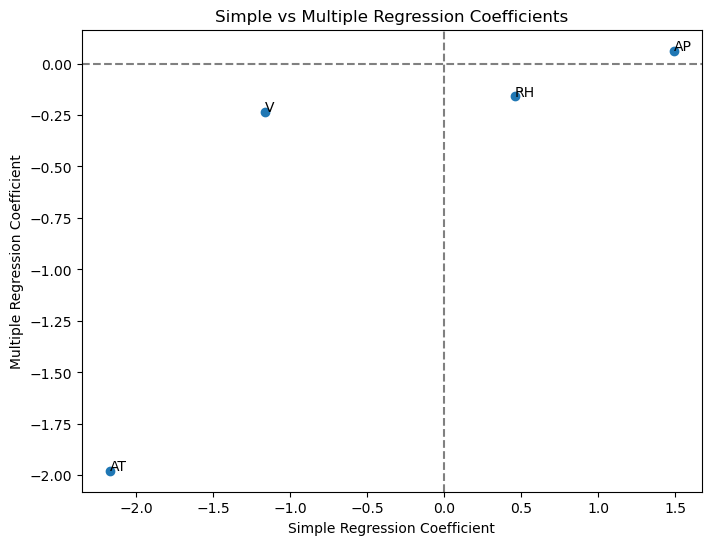

In [8]:
uni_coefs = []
for predictor in predictors:
    X = sm.add_constant(df[predictor])
    y = df['PE']
    m = sm.OLS(y, X).fit()
    uni_coefs.append(m.params[predictor])

multi_coefs = [model_multi.params[p] for p in predictors]

plt.figure(figsize=(8, 6))
plt.scatter(uni_coefs, multi_coefs)
for i, p in enumerate(predictors):
    plt.annotate(p, (uni_coefs[i], multi_coefs[i]))
plt.xlabel('Simple Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Simple vs Multiple Regression Coefficients')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.show()

**Results:** 

AT and AP have similar coefficients in both models, they being pretty consistent. V in simple regression has a lot lower coefficient, and RH even flips the sign from positive in simple to negative in multiple.

### (f) Nonlinear Association

In [9]:
for predictor in predictors:
    X = df[predictor]
    X_poly = pd.DataFrame({
        predictor: X,
        predictor + '^2': X**2,
        predictor + '^3': X**3
    })
    X_poly = sm.add_constant(X_poly)
    y = df['PE']

    model_poly = sm.OLS(y, X_poly).fit()
    print(f" Cubic Model: PE ~ {predictor} + {predictor}^2 + {predictor}^3 ")
    print(model_poly.summary())
    print("\n")

 Cubic Model: PE ~ AT + AT^2 + AT^3 
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:35:41   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        49

**Results:** For AT, AP, and RH, both the squared and cubic terms are significant (p < 0.05), showing nonlinear relationships with PE.  
For V, the squared term is not significant (p=0.768), but the cubic term is (p=0.014), suggesting a weaker/different nonlinear pattern.

### (g) Interactions of Predictors

In [10]:
X_int = df[predictors].copy()

for p1, p2 in combinations(predictors, 2):
    X_int[f'{p1}*{p2}'] = df[p1] * df[p2]

X_int = sm.add_constant(X_int)
y = df['PE']

model_int = sm.OLS(y, X_int).fit()
print(model_int.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:35:41   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

**Results:** Four interaction terms are significant: AT*V, AT*RH, V*AP, AP*RH (p < 0.05). Two are not significant: AT*AP (p=0.452) and V*RH (p=0.086).  
Adding interactions improved R² slightly (0.929 → 0.936). 

### (h) Improvement

In [11]:

# Split data: 70% train, 30% test

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

print(train_df.shape, test_df.shape)

(6697, 5) (2871, 5)


In [12]:
# Model 1: multiple regression with all four predictors, no interactions/nonlinear terms
X_train1 = sm.add_constant(train_df[predictors])
y_train = train_df['PE']
model1 = sm.OLS(y_train, X_train1).fit()

X_test1 = sm.add_constant(test_df[predictors])
y_test = test_df['PE']

# Predict on both train and test
train_pred1 = model1.predict(X_train1)
test_pred1 = model1.predict(X_test1)

# Compute MSE
train_mse1 = mean_squared_error(y_train, train_pred1)
test_mse1 = mean_squared_error(y_test, test_pred1)

print(f"Model 1 (all predictors) — Train MSE: {train_mse1:.4f}, Test MSE: {test_mse1:.4f}")

Model 1 (all predictors) — Train MSE: 20.5808, Test MSE: 21.2399


In [13]:
# Build a feature set with all predictors, all pairwise interactions, and all squared terms
def build_full_features(data):
    feat = data[predictors].copy()
    # Add pair wise interaction terms
    for p1, p2 in combinations(predictors, 2):
        feat[f'{p1}*{p2}'] = data[p1] * data[p2]
    # Add squared (quadratic) terms
    for p in predictors:
        feat[f'{p}^2'] = data[p] ** 2
    return feat

X_train_full = sm.add_constant(build_full_features(train_df))
model_full = sm.OLS(y_train, X_train_full).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:35:41   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7664.9809   1429.568     -5.362      0.0

In [14]:
# Because AT*AP (p=0.197), V*AP (p=0.381), V*RH (p=0.867), V^2 (p=0.700) so we gonna drop them
# We keep V because AT*V interaction is significant

features_to_drop = ['AT*AP', 'V*AP', 'V*RH', 'V^2']

X_train_reduced = X_train_full.drop(columns=features_to_drop)
model2 = sm.OLS(y_train, X_train_reduced).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:35:41   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.046e+04   1091.512     -9.581      0.0

In [15]:
# Build the same reduced feature set on the test data
X_test_full = sm.add_constant(build_full_features(test_df))
X_test_reduced = X_test_full.drop(columns=features_to_drop)

# Predict using model2 on train and test sets
train_pred2 = model2.predict(X_train_reduced)
test_pred2 = model2.predict(X_test_reduced)

# Compute MSE for model2
train_mse2 = mean_squared_error(y_train, train_pred2)
test_mse2 = mean_squared_error(y_test, test_pred2)

print(f"Model 1 (all predictors)         — Train MSE: {train_mse1:.4f}, Test MSE: {test_mse1:.4f}")
print(f"Model 2 (interactions + squares) — Train MSE: {train_mse2:.4f}, Test MSE: {test_mse2:.4f}")

Model 1 (all predictors)         — Train MSE: 20.5808, Test MSE: 21.2399
Model 2 (interactions + squares) — Train MSE: 17.9178, Test MSE: 18.6943


**Results:** Model 2 has lower MSE than Model 1 on both train (17.92 vs 20.58) and test (18.69 vs 21.24) sets.  

The gap between train and test MSE is small for both models, so Model 2 is not overfitting.

### (i) KNN

In [16]:
# Raw features, no scaling
X_train_raw = train_df[predictors].values
X_test_raw = test_df[predictors].values

y_train_vals = train_df['PE'].values
y_test_vals = test_df['PE'].values

# Normalized features: scale to mean=0, std=1
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)


In [17]:
# k values to test
k_values = list(range(1, 101))

train_errors_raw = []
test_errors_raw = []

# KNN regression using raw (unscaled) features
for k in k_values:
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train_raw, y_train_vals)

    train_pred = knn_raw.predict(X_train_raw)
    test_pred = knn_raw.predict(X_test_raw)

    train_errors_raw.append(mean_squared_error(y_train_vals, train_pred))
    test_errors_raw.append(mean_squared_error(y_test_vals, test_pred))

train_errors_norm = []
test_errors_norm = []

# KNN regression using normalized features
for k in k_values:
    knn_norm = KNeighborsRegressor(n_neighbors=k)
    knn_norm.fit(X_train_norm, y_train_vals)

    train_pred = knn_norm.predict(X_train_norm)
    test_pred = knn_norm.predict(X_test_norm)

    train_errors_norm.append(mean_squared_error(y_train_vals, train_pred))
    test_errors_norm.append(mean_squared_error(y_test_vals, test_pred))

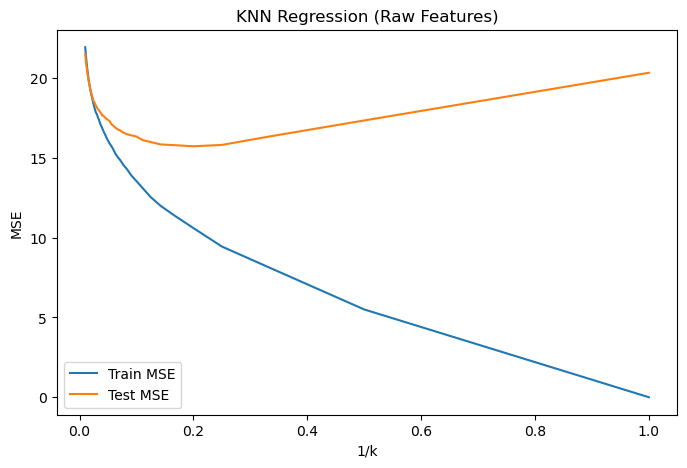

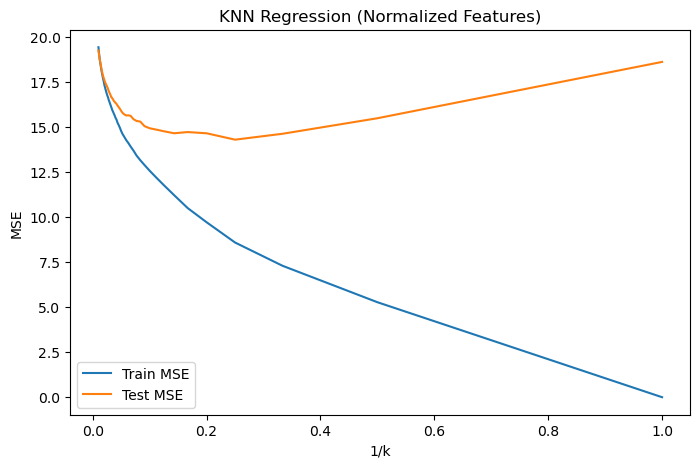

In [18]:
# Convert k to 1/k
inv_k = [1/k for k in k_values]

# Plot for raw features
plt.figure(figsize=(8, 5))
plt.plot(inv_k, train_errors_raw, label='Train MSE')
plt.plot(inv_k, test_errors_raw, label='Test MSE')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression (Raw Features)')
plt.legend()
plt.show()

# Plot for normalized features
plt.figure(figsize=(8, 5))
plt.plot(inv_k, train_errors_norm, label='Train MSE')
plt.plot(inv_k, test_errors_norm, label='Test MSE')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression (Normalized Features)')
plt.legend()
plt.show()



In [19]:
# Find best k (lowest test MSE) for raw and normalized features
best_k_raw = k_values[np.argmin(test_errors_raw)]
best_k_norm = k_values[np.argmin(test_errors_norm)]

print(f"Best k (raw features): {best_k_raw}, Test MSE: {min(test_errors_raw):.4f}")
print(f"Best k (normalized features): {best_k_norm}, Test MSE: {min(test_errors_norm):.4f}")

Best k (raw features): 5, Test MSE: 15.7268
Best k (normalized features): 4, Test MSE: 14.3057


### (j ) Compare KNN and Linear

**Results:** KNN (normalized, k=4) has Test MSE = 14.31. This is lower than the best linear model (Model 2, Test MSE = 18.69). So KNN performs better here.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible statistical learning method is better here. Becuase Large n reduces overfitting risk, so a flexible method can fit the true pattern well without high variance.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

An inflexible method in this case is better. Small n means a flexible method would overfit (high variance).

### (c) The relationship between the predictors and response is highly non-linear.

Flexible here is better. Inflexible methods can't capture nonlinear patterns, causing high bias.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

AN inflexible method is better here. High noise means a flexible method would fit the noise itself, causing an increasing variance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

Obs 1: sqrt(0² + 3² + 0²) = 3  
Obs 2: sqrt(2² + 0² + 0²) = 2  
Obs 3: sqrt(0² + 1² + 3²) = sqrt(10) ≈ 3.16  
Obs 4: sqrt(0² + 1² + 2²) = sqrt(5) ≈ 2.24  
Obs 5: sqrt((-1)² + 0² + 1²) = sqrt(2) ≈ 1.41  
Obs 6: sqrt(1² + 1² + 1²) = sqrt(3) ≈ 1.73   

### (b) What is our prediction with K = 1? Why?

My prediction is Green with K=1. we only look at the single nearest neighbor, which is Obs 5 (distance ≈ 1.41, label = Green). So it should be Green.

### (c) What is our prediction with K = 3? Why?

My prediction is Red when K=3, Because the 3 nearest neighbors are Obs 5 (Green), Obs 6 (Red), and Obs 2 (Red). 2 out of 3 are Red, so majority voting gives Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect the best value for K to be small. Because a small K lets the model follow complex, curvy boundaries closely. Large K smooths things out too much and will miss the nonlinear pattern.